<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/EDP-1/blob/main/Caminata_aleatoria2_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Caminata aleatoria 1D

**Instrucciones**
En una notebook de Jupyter, escribir un código que implemente una caminata aleatoria 1D, con probabilidad p de moverse a la derecha y probabilidad q de moverse a la izquierda, tal que p + q = 1.
La notebook debe incluir explicación con ecuaciones en LaTex.
El código debe graficar las trayectorias y permitir elegir valores para p.

Se califica:
* Presentación.
* Completez.
* Funcionamiento.
* Incluir una sección final de análisis y conclusiones.

El uso indiscriminado de IA será motivo de cancelación de la tarea.

Entregar esta tarea en github: poner solamente el link al repositorio correspondiente. No se aceptan archivos ni enlaces a Drive.



Una caminata aleatoria unidimensional es un proocesos estocástico donde una particula se mueve sobre una recta númerica dando pasos discretos.

En cada paso $n$, la partícula:

- Se mueve ** a la derecha** con probabilidad $p$
- Se mueve ** a la izquierda** con probabilidad $q$

Donde:

$$ p+q=1 \rightarrow\quad q= 1-p $$

Si llamamos a $X_n$ a la posición en el paso $n$, entonces:

$$ X_{n+}= X_n + xi_{n+1} $$


donde $xi_{n+1} $ es una variable aleatoria que toma valores:

$
xi_{n+1}= \begin{cases}
+1 & \text{con probabilidad} p\\
-1 & \text{con probabilidad} q
\end{cases}
$


In [21]:
import random #genera números aleatorios
import matplotlib.pyplot as plt #grafica

Definimos los parámetros:


* $p$ es la probabilidad de moverse a la derecha, la cual debe cumplir $ 0 \le p \le 1$

* $ q= 1-p$ es la probabilidad de moverse a la izquierda
* $N$ son los número de pasos que daremos

Definiremos la función de la caminata de 1D de N pasos.


In [24]:
def caminata_1d (p,N):

  """
  Parámetros:
    p: **float** probabilidad de moverse a al derecha.
    N: **int** Número de pasos.

  Devuelve:
    lista_posiciones: list
    Lista con la posicion en cada paso (incluye el paso 0)
  """
  q=1-p #definimos q como la probabilidad de ir a la izquierda
  x=20  #poscicion inicial (k=20)
  lista_posiciones= [x]  #lista para guardad la posición en cada paso

  for _ in range(N):
    r= random.random()  #genera un úmero aleatorio uniforme entre 0 y 1

    """
    Si r < p -> se mueve a la derecha (+1)
    si r >= p -> se mueve a la izquierda (-1)

    """

    if r < p:
      x += 1
    else:
      x -= 1


    lista_posiciones.append (x) #guarda la nueva posición
  return lista_posiciones

Gráficare $M$ trayectorias de caminata aleatoria 1D con N pasos y probabilidad $p$

In [25]:
def graficar_trayectorias(p, N, M):

    plt.figure(figsize=(10, 6))

    # Generamos y graficamos M trayectorias
    for i in range(M):
        trayectoria = caminata_1d(p, N)
        plt.plot(trayectoria, linewidth=1, alpha=0.8)

    # Línea del origen para referencia
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.title(f"Trayectorias de Caminata Aleatoria 1D (p = {p})")
    plt.xlabel("Pasos (n)")
    plt.ylabel("Posición X(n)")
    plt.grid(alpha=0.3)
    plt.show()

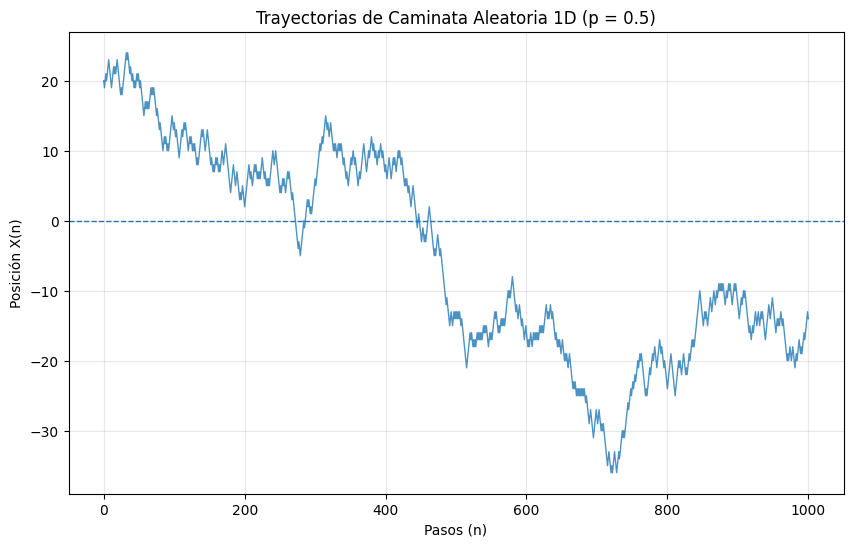

In [26]:
# Parámetros
N =1000 #pasos
M = 1 #Número de trayectorias a gráficar

#probabilidades a probar
valores_p = [ 0.5]

for p in valores_p:
   graficar_trayectorias (p, N , M)

Para una caminata aleatoria con 100 pasos

- Si $p=0.5$, la caminata es **simetrica**: la trayectoria fluctúa.

- Si $p>0.5$, tiende a **crecer** hacia la derecha.

- Si $p< 0.5$, tiende a **disminuir**: hacia la izquierda.

In [27]:

num_juegos = 1000
N = 1000
p = 0.5
limite_superior = 60

x0 = 20   # tu función ya usa x=20, pero lo dejamos documentado

llega_a_cero = 0   # contador de éxitos

for _ in range(num_juegos):

    trayectoria = caminata_1d(p, N)   # usamos tu función 😊

    # Verificamos si la caminata toca 0 o 60
    if 0 in trayectoria:
        llega_a_cero += 1

# Probabilidad estimada
probabilidad = llega_a_cero / num_juegos

print("\nRESULTADOS DEL EXPERIMENTO")
print("="*40)
print(f"Juegos simulados: {num_juegos}")
print(f"Veces que la caminata llegó a 0: {llega_a_cero}")
print(f"Probabilidad estimada de llegar a 0 : {probabilidad:.4f}")


RESULTADOS DEL EXPERIMENTO
Juegos simulados: 1000
Veces que la caminata llegó a 0: 527
Probabilidad estimada de llegar a 0 : 0.5270



##PREGUNTAS
1. Cuál es media, varianza y desviación estandar. Recordando las deficiones, sabemos.

  * MEDIA(PROMEDIO): La media empirica se define como:

   $$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $$
   
   donde $n$ es el numero total de observaciones(datos).

  * VARIANZA: Mide la dispersión de los datos a ala media y se define como:

$$ \mathrm{Var}(X) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$


* DESVIACIÓN ESTANDAR: Es la raíz cuadrada de la varianza:

$$\sigma = \sqrt{\mathrm{Var}(X)}$$

Estas cantidades me permitiran analizar la tendencia y la variabilidad de las trayectorias de la caminata aleatoria.

In [ ]:
p = 0.5
N = 60
trayectoria = caminata_1d (p,N)

In [ ]:
# ----Media-----

#número total de datos
n= len(trayectoria)
media =sum(trayectoria)/N


#----calculo de la varianza----

varianza =0
for xi in trayectoria:
  varianza += (xi-media)**2
  varianza = varianza/n


#----desviación estandar----

desviacion_estandar = varianza**0.5


print(f"Media: {media}")
print(f"Varianza: {varianza}")
print(f"Desviación estandar: {desviacion_estandar}")


Media: 2.14
Varianza: 0.034325999991774055
Desviación estandar: 0.18527277185753457


Con $p=0.5$ y $N=100$, la caminata es simétrica, por lo que:

* La media obtenida fue de $\bar{x}=2.14$ lo cual esta relativamente cerca de 0, lo cual es correcto ante el procediemiento aleatorio.

* La varianza pequeña indica que, en esta trayectoria, no se alejaron tanto del promedio



2. Cúal fue la posición:

  * posición final
  * posición maxima
  * posición minima
  * cuantas veces paso por el 0

In [ ]:
#cálculos estadísticos

posicion_final = trayectoria[-1]
posicion_max = max(trayectoria)
posicion_min = min (trayectoria)

# Contador de cuantas veces toco el origen

toco_origen = 0

for pos in trayectoria:
   if pos == 0:
       toco_origen += 1


print ("ANÁLISIS DE LA TRAYECTORIA CUANDO p=0.5 y N=100")
print ("="*40)
print(f"Posición final: {posicion_final}")
print(f"Posición máxima: {posicion_max}")
print(f"Posición min: {posicion_min}")
print(f"Veces que tocó el origen: {toco_origen}")

ANÁLISIS DE LA TRAYECTORIA CUANDO p=0.5 y N=100
Posición final: 4
Posición máxima: 6
Posición min: -3
Veces que tocó el origen: 14


Notemos que la camimata aleatoria 1D con probabilidad $p$ de moverse a la derecha y $q=1-p$ a la izquierda.

Las trayectorias muestran el comportamiento fluctuante; es decir cambia sucesivamente.

Cuando p= 0.5, la caminata es simétrica y no presenta hacia ningún lado. Además, al tratarse de un proceso aleatorio, los resultado no seran lo mismo en cada ejecución, ya que cada trayectoria depende de los números generados al azar.


Aunque cada ejecución da resultados diferentes, el comportamiento coincide con lo esperado.

Cuál es la probabilidad de que la trayectoria llegue a 0


Si llega a 0